In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
large = pd.read_parquet("../outputs/large_clean.parquet")
scalar = pd.read_parquet("../outputs/scalar_clean.parquet")

with open("../outputs/genre_label_map.json", "r") as f:
    genre_label_map = json.load(f)

print("Large shape:", large.shape)
print("Scalar shape:", scalar.shape)

Large shape: (13543, 4)
Scalar shape: (394, 37)


### Label and Genre distribution

In [3]:
large_label_dist = large["Label"].value_counts().to_frame("count")
large_label_dist["percent"] = large_label_dist["count"] / len(large) * 100

scalar_label_dist = scalar["Reader_Predicted_Label"].value_counts().to_frame("count")
scalar_label_dist["percent"] = scalar_label_dist["count"] / len(scalar) * 100

display(large_label_dist)
display(scalar_label_dist)



,count,percent
Label,,
POS,8373,61.825297
NEG,5170,38.174703


,count,percent
Reader_Predicted_Label,,
1,214,54.314721
0,180,45.685279


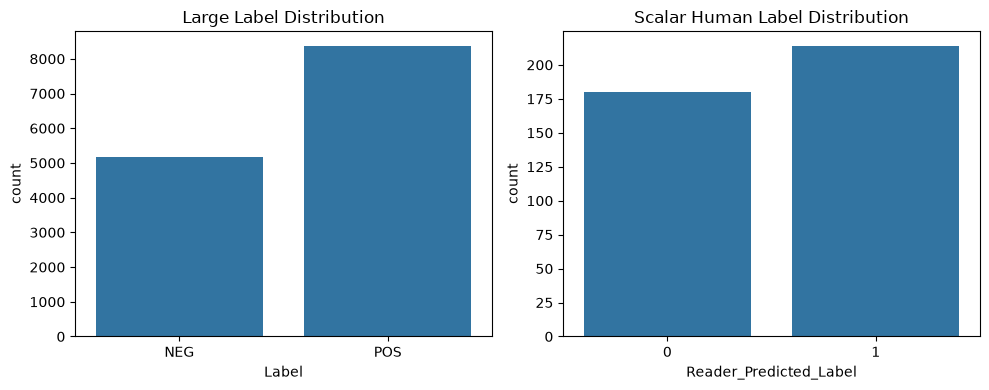

In [4]:
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(data=large, x="Label", ax=axes[0])
axes[0].set_title("Large Label Distribution")

sns.countplot(data=scalar, x="Reader_Predicted_Label", ax=axes[1])
axes[1].set_title("Scalar Human Label Distribution")

plt.tight_layout()
plt.savefig(FIG_DIR / "label_distribution_large_scalar.png", dpi=300)
plt.show()

In [5]:
large_genre_dist = large["Genre"].value_counts().to_frame("count")
large_genre_dist["percent"] = large_genre_dist["count"] / len(large) * 100

scalar_genre_dist = scalar["GENRE"].value_counts().to_frame("count")
scalar_genre_dist["percent"] = scalar_genre_dist["count"] / len(scalar) * 100

display(large_genre_dist)
display(scalar_genre_dist)

,count,percent
Genre,,
LEGAL,1054,7.782618
NOVEL19C,998,7.369121
HIST,979,7.228827
ROC,976,7.206675
REDDIT,971,7.169756
ABSTRACT,950,7.014694
SCOTUS,942,6.955623
MEM,935,6.903936
BIO,898,6.630732


,count,percent
GENRE,,
BREVIEW,38,9.644670
SCOTUS,35,8.883249
LEGAL,31,7.868020
ABSTRACT,26,6.598985
HIST,25,6.345178
NOVEL19C,25,6.345178
NOVEL-CONT,23,5.837563
ROC,23,5.837563
MEM,22,5.583756


In [6]:
genre_label_ct = pd.crosstab(large["Genre"], large["Label"])
genre_label_pct = pd.crosstab(large["Genre"], large["Label"], normalize="index") * 100

display(genre_label_ct)
display(genre_label_pct.round(2))

Label,NEG,POS
Genre,,
ABSTRACT,950,0
APHORISM,461,0
BIO,0,898
BREVIEW,776,0
FABLE,0,258
FAIRY,0,740
FLASH,0,391
HIST,0,979
LEGAL,1054,0


Label,NEG,POS
Genre,,
ABSTRACT,100.0,0.0
APHORISM,100.0,0.0
BIO,0.0,100.0
BREVIEW,100.0,0.0
FABLE,0.0,100.0
FAIRY,0.0,100.0
FLASH,0.0,100.0
HIST,0.0,100.0
LEGAL,100.0,0.0


In [7]:
genre_label_nunique = large.groupby("Genre")["Label"].nunique()

print("Genres with exactly one label:", (genre_label_nunique == 1).sum())
print("Total genres:", genre_label_nunique.shape[0])

genre_label_nunique

Genres with exactly one label: 18
Total genres: 18


Genre
ABSTRACT      1
APHORISM      1
BIO           1
BREVIEW       1
FABLE         1
FAIRY         1
FLASH         1
HIST          1
LEGAL         1
LITSTUDY      1
MEM           1
NOVEL-CONT    1
NOVEL19C      1
PHIL          1
REDDIT        1
ROC           1
SCOTUS        1
SHORT         1
Name: Label, dtype: int64

In [8]:
TABLE_DIR = Path("../outputs/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)
genre_label_ct.to_csv(TABLE_DIR / "large_genre_label_crosstab.csv")
genre_label_pct.round(2).to_csv(TABLE_DIR / "large_genre_label_crosstab_percent.csv")

In [9]:
if (genre_label_nunique == 1).all():
    print("Conclusion: In Large, Label is 100% determined by Genre.")
else:
    print("Conclusion: Some genres map to more than one label.")

Conclusion: In Large, Label is 100% determined by Genre.


### Text Length Analysis

In [10]:
def add_lengths(df, text_col):
    df = df.copy()
    df["char_len"] = df[text_col].astype(str).str.len()
    df["word_len"] = df[text_col].astype(str).str.split().str.len()
    return df

large = add_lengths(large, "Text")
scalar = add_lengths(scalar, "TEXT")

In [11]:
length_summary = pd.DataFrame({
    "Dataset": ["Large", "Scalar", "PHEME Tweets"],
    "Median_Words": [
        large["word_len"].median(),
        scalar["word_len"].median(),
        15
    ],
    "Mean_Words": [
        large["word_len"].mean(),
        scalar["word_len"].mean(),
        np.nan
    ],
    "P95_Words": [
        large["word_len"].quantile(0.95),
        scalar["word_len"].quantile(0.95),
        np.nan
    ]
})

length_summary

,Dataset,Median_Words,Mean_Words,P95_Words
0,Large,104.0,115.618401,238.0
1,Scalar,111.0,121.870558,252.7
2,PHEME Tweets,15.0,NaN,NaN


In [12]:
length_summary.to_csv(TABLE_DIR / "text_length_summary.csv", index=False)

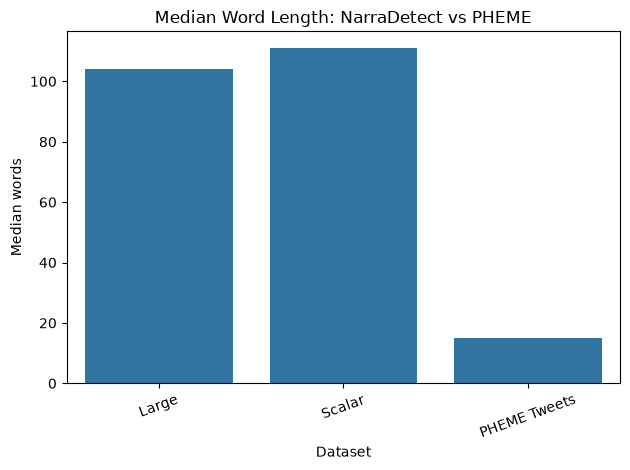

In [13]:
sns.barplot(data=length_summary, x="Dataset", y="Median_Words")
plt.title("Median Word Length: NarraDetect vs PHEME")
plt.ylabel("Median words")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "median_word_length_comparison.png", dpi=300)
plt.show()

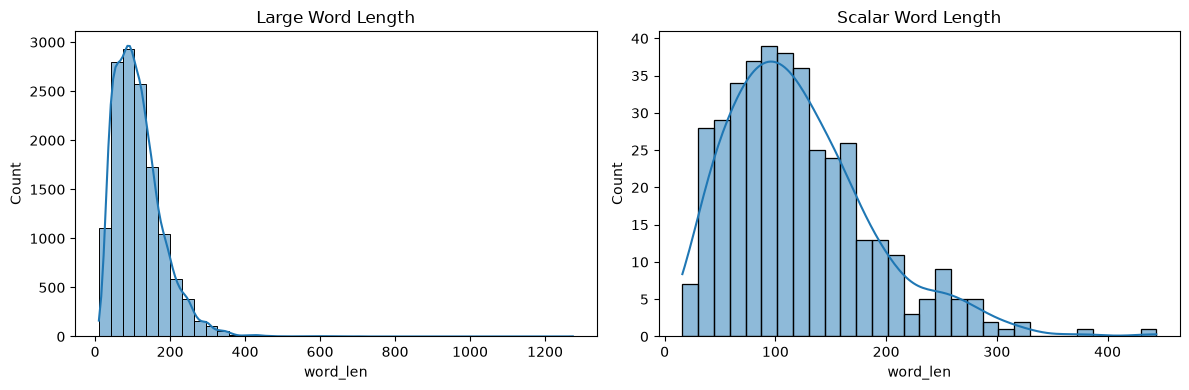

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(large["word_len"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Large Word Length")

sns.histplot(scalar["word_len"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Scalar Word Length")

plt.tight_layout()
plt.savefig(FIG_DIR / "word_length_distribution.png", dpi=300)
plt.show()

In [15]:
word_percentiles = pd.DataFrame({
    "Percentile": [50, 75, 90, 95, 99],
    "Large_Words": np.percentile(large["word_len"], [50, 75, 90, 95, 99]),
    "Scalar_Words": np.percentile(scalar["word_len"], [50, 75, 90, 95, 99])
})

word_percentiles

,Percentile,Large_Words,Scalar_Words
0,50,104.0,111.00
1,75,148.0,157.25
2,90,200.0,206.40
3,95,238.0,252.70
4,99,318.0,312.63


In [16]:
word_percentiles.to_csv(TABLE_DIR / "word_length_percentiles.csv", index=False)

### Regression target: avg_overall

In [17]:
target_summary = scalar["avg_overall"].describe()
target_summary

count    394.000000
mean       3.208122
std        1.334460
min        1.000000
25%        1.888889
50%        3.333333
75%        4.555556
max        5.000000
Name: avg_overall, dtype: float64

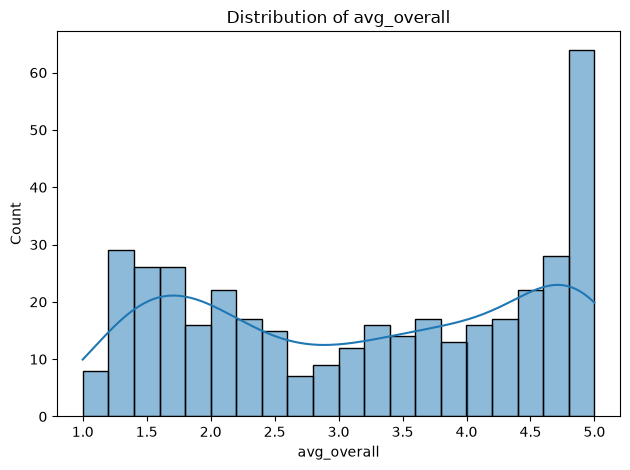

In [18]:
sns.histplot(scalar["avg_overall"], bins=20, kde=True)
plt.title("Distribution of avg_overall")
plt.xlabel("avg_overall")
plt.tight_layout()
plt.savefig(FIG_DIR / "avg_overall_distribution.png", dpi=300)
plt.show()

In [19]:
subscale_cols = ["avg_agency", "avg_event_seq", "avg_worldmaking"]

subscale_summary = scalar[subscale_cols + ["avg_overall"]].describe()
subscale_summary

,avg_agency,avg_event_seq,avg_worldmaking,avg_overall
count,394.000000,394.000000,394.000000,394.000000
mean,3.156514,3.315567,3.152284,3.208122
std,1.410424,1.262974,1.476397,1.334460
min,1.000000,1.000000,1.000000,1.000000
25%,1.666667,2.333333,1.666667,1.888889
50%,3.333333,3.333333,3.333333,3.333333
75%,4.666667,4.666667,4.666667,4.555556
max,5.000000,5.000000,5.000000,5.000000


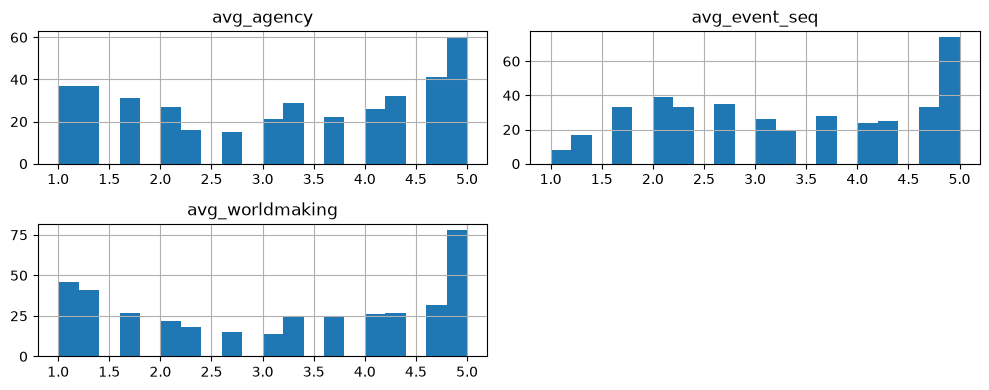

In [20]:
scalar[subscale_cols].hist(figsize=(10,4), bins=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "subscale_distributions.png", dpi=300)
plt.show()

In [21]:
scalar["avg_overall"].describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

count    394.000000
mean       3.208122
std        1.334460
min        1.000000
10%        1.444444
25%        1.888889
50%        3.333333
75%        4.555556
90%        4.888889
max        5.000000
Name: avg_overall, dtype: float64

In [22]:
scalar["avg_overall"].skew()

np.float64(-0.07104176713099047)

### Inter-coder reliability

In [23]:
scalar["AvgDeviation"].describe()

count    394.000000
mean       0.406843
std        0.307726
min        0.000000
25%        0.148148
50%        0.370370
75%        0.592593
max        1.629630
Name: AvgDeviation, dtype: float64

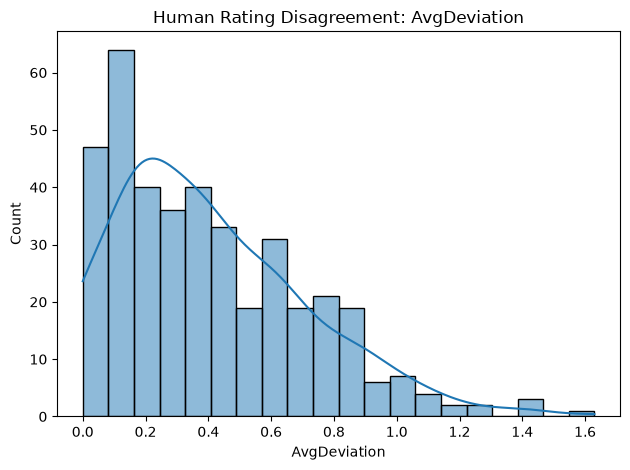

In [24]:
sns.histplot(scalar["AvgDeviation"], bins=20, kde=True)
plt.title("Human Rating Disagreement: AvgDeviation")
plt.xlabel("AvgDeviation")
plt.tight_layout()
plt.savefig(FIG_DIR / "avgdeviation_distribution.png", dpi=300)
plt.show()

In [25]:
coder_overall_cols = [
    col for col in scalar.columns
    if "overall" in col.lower() and any(coder in col for coder in ["AY", "ML", "LM"])
]

coder_overall_cols

['AY_overall', 'ML_overall', 'LM_overall']

In [26]:
coder_stats = scalar[coder_overall_cols].agg(["mean", "std"]).T
coder_stats

,mean,std
AY_overall,3.485618,1.403957
ML_overall,3.050761,1.423863
LM_overall,3.087986,1.474364


In [27]:
coder_stats.to_csv(TABLE_DIR / "coder_overall_stats.csv")

In [28]:
coder_corr = scalar[coder_overall_cols].corr()
coder_corr

,AY_overall,ML_overall,LM_overall
AY_overall,1.000000,0.798317,0.786529
ML_overall,0.798317,1.000000,0.811448
LM_overall,0.786529,0.811448,1.000000


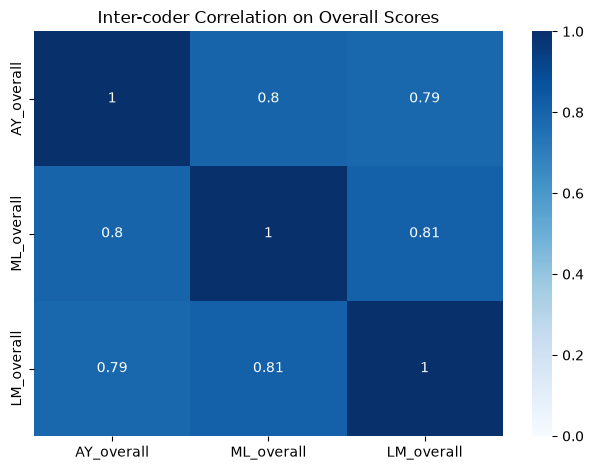

In [29]:
sns.heatmap(coder_corr, annot=True, vmin=0, vmax=1, cmap="Blues")
plt.title("Inter-coder Correlation on Overall Scores")
plt.tight_layout()
plt.savefig(FIG_DIR / "intercoder_correlation.png", dpi=300)
plt.show()

In [30]:
high_disagreement = scalar.sort_values("AvgDeviation", ascending=False).head(10)

high_disagreement[[
    "ID",
    "GENRE",
    "Reader_Predicted_Label",
    "avg_overall",
    "AvgDeviation",
    "TEXT"
]]

,ID,GENRE,Reader_Predicted_Label,avg_overall,AvgDeviation,TEXT
149,u956m55myc8m,FLASH,1,3.444444,1.629630,"A woman chastises him. I am afraid, on alert. ..."
271,kojbib8vvbbn,NOVEL19C,0,2.555556,1.407407,Women almost had their heels sliced off. Amor ...
257,d2mw93qzqm2m,NOVEL-CONT,0,2.888889,1.407407,"It’s a big secret. But I’ll tell you, Leonard,..."
148,to9w4p9p9ica,FLASH,1,3.111111,1.407407,They need to laugh and throw candy through\nth...
227,a0ydr79xlqmb,MEM,1,3.222222,1.259259,I have two beautiful children under the age of...
258,i5uafz5sccdh,NOVEL-CONT,1,3.888889,1.259259,I don’t know if it was the head trauma or the ...
263,dniy1pi4929e,NOVEL19C,1,3.222222,1.185185,"My good friend,' asked Arsenius, in a tremblin..."
253,ptxl6ifbzgvr,NOVEL-CONT,0,2.777778,1.185185,“So…” She fought the urge to ask everything ab...
15,l06uzrd39woh,LITSTUDY,1,3.333333,1.111111,"It was there two days ago.”\nShe was firm, det..."
280,cmnieuy4tskq,NOVEL19C,1,3.333333,1.111111,"""A country boy brought it,"" answered the serva..."


In [31]:
for threshold in [0.5, 0.75, 1.0, 1.25, 1.5]:
    dropped = (scalar["AvgDeviation"] > threshold).sum()
    print(
        f"Threshold > {threshold}: drop {dropped} rows "
        f"({dropped / len(scalar) * 100:.2f}%)"
    )

Threshold > 0.5: drop 134 rows (34.01%)
Threshold > 0.75: drop 51 rows (12.94%)
Threshold > 1.0: drop 19 rows (4.82%)
Threshold > 1.25: drop 6 rows (1.52%)
Threshold > 1.5: drop 1 rows (0.25%)


### Sub-scale correlation and label separation

In [32]:
subscale_corr = scalar[subscale_cols].corr()
subscale_corr

,avg_agency,avg_event_seq,avg_worldmaking
avg_agency,1.000000,0.864981,0.919518
avg_event_seq,0.864981,1.000000,0.898764
avg_worldmaking,0.919518,0.898764,1.000000


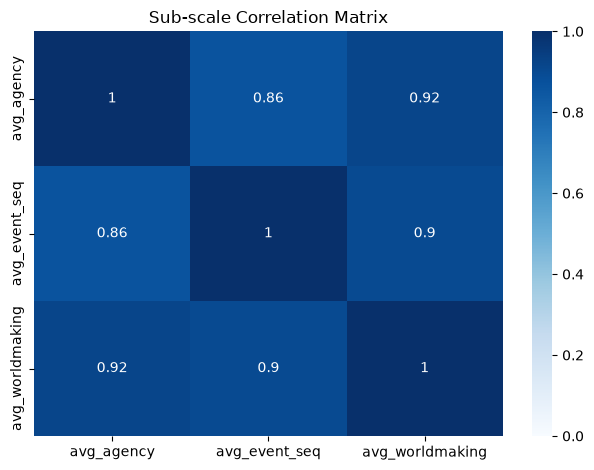

In [33]:
sns.heatmap(subscale_corr, annot=True, vmin=0, vmax=1, cmap="Blues")
plt.title("Sub-scale Correlation Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR / "subscale_correlation_matrix.png", dpi=300)
plt.show()

In [34]:
subscale_by_label = scalar.groupby("Reader_Predicted_Label")[subscale_cols + ["avg_overall"]].mean()
subscale_by_label

,avg_agency,avg_event_seq,avg_worldmaking,avg_overall
Reader_Predicted_Label,,,,
0,1.809259,2.15000,1.727778,1.895679
1,4.289720,4.29595,4.350467,4.312046


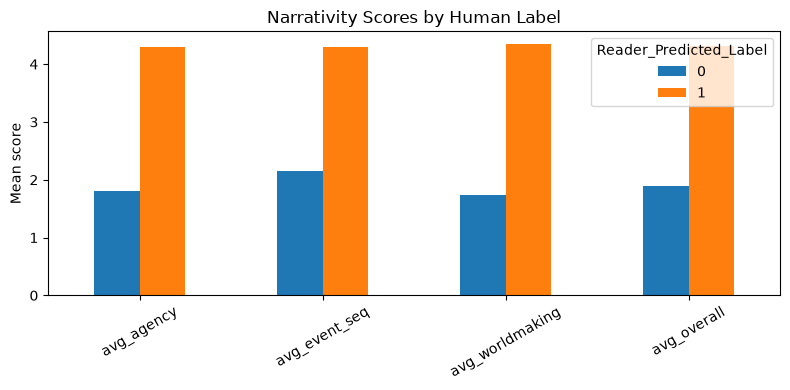

In [35]:
subscale_by_label.T.plot(kind="bar", figsize=(8,4))

plt.title("Narrativity Scores by Human Label")
plt.ylabel("Mean score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "subscale_means_by_label.png", dpi=300)
plt.show()

In [36]:
subscale_by_genre = scalar.groupby("GENRE")[subscale_cols + ["avg_overall"]].mean()
subscale_by_genre

,avg_agency,avg_event_seq,avg_worldmaking,avg_overall
GENRE,,,,
ABSTRACT,1.487179,2.705128,1.743590,1.978632
APHORISM,1.649123,2.000000,1.614035,1.754386
BIO,3.843137,3.745098,3.705882,3.764706
BREVIEW,3.000000,2.894737,3.263158,3.052632
FABLE,4.800000,4.766667,4.833333,4.800000
FAIRY,4.216667,4.066667,4.250000,4.177778
FLASH,4.055556,4.055556,4.222222,4.111111
HIST,3.733333,4.106667,3.826667,3.888889
LEGAL,1.591398,1.935484,1.268817,1.598566


In [37]:
subscale_corr.to_csv(TABLE_DIR / "subscale_correlation_matrix.csv")
subscale_by_label.to_csv(TABLE_DIR / "subscale_by_label.csv")
subscale_by_genre.to_csv(TABLE_DIR / "subscale_by_genre.csv")